In [ ]:
prediction_length=1
context_length=12
batch_size=1
epochs = 200
from transformers import InformerConfig, InformerModel,InformerForPrediction,AutoformerForPrediction,AutoformerConfig
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [ ]:
df = pd.DataFrame()
a = input("the threee batteries")
a = a.split(",")
for i in a:
  df = pd.concat([df,pd.read_csv(f"{i}_health_index_updated.csv")])
df.head()
b = input("target battery")
df1 = pd.read_csv(f"{b}_health_index_updated.csv")
df1.head()

the threee batteriesB0007,B0018
target batteryB0006


,cycle,capacity,IC_C_H,IC_C_P,IC_D_H,IC_D_P
0,1,2.035338,192559.513499,4.113459,25025.017506,3.487328
1,2,2.025140,286935.820861,3.980853,25248.241155,3.501864
2,3,2.013326,397674.737321,4.201716,26611.372173,3.502912
3,4,2.013285,419097.869539,4.201716,27649.237199,3.500828
4,5,2.000528,887704.283499,4.002199,28131.143826,3.498477


In [ ]:
df["datetime"] = pd.to_datetime(df["datetime"],format="%d-%m-%Y")

KeyError: 'datetime'

In [ ]:
def preprocess_data(df):
  df["datetime"] = pd.to_datetime(df["datetime"])
  df["year"] = df["datetime"].dt.year
  df["month"] = df["datetime"].dt.month
  df["day"] = df["datetime"].dt.day
  df["weekday"] = df["datetime"].dt.weekday

  return df


In [ ]:
df = pd.read_csv("B0005_health_index_updated.csv")
df.head()

,cycle,capacity,IC_C_H,IC_C_P,IC_D_H,IC_D_P
0,1,1.856487,88289.812972,4.206847,22830.110320,3.480996
1,2,1.846327,59498.182092,3.971994,24381.926803,3.501615
2,3,1.835349,64157.533263,4.210378,24668.755808,3.484151
3,4,1.835263,85564.969350,3.998606,25125.648268,3.497942
4,5,1.834646,511873.161957,3.977384,21963.459433,3.512115


In [ ]:
# df = preprocess_data(df)
train , test = train_test_split(df, test_size=0.5,shuffle=False)
# train , test = df,df1

In [ ]:
test

,cycle,capacity,IC_C_H,IC_C_P,IC_D_H,IC_D_P
84,85,1.538237,9.118420e+05,3.956088,17520.190615,3.439597
85,86,1.527914,2.271676e+06,4.044475,16747.871479,3.495146
86,87,1.528525,4.161850e+06,4.082412,15815.977328,3.457821
87,88,1.522647,1.354629e+06,4.024366,16697.398613,3.502801
88,89,1.517486,3.259509e+06,4.000249,19951.647020,3.479101
...,...,...,...,...,...,...
163,164,1.293464,5.458747e+05,4.119117,13094.050155,3.475353
164,165,1.288003,4.226070e+05,4.152133,11034.425008,3.436022
165,166,1.287453,5.021473e+05,4.074138,11912.252794,3.409309
166,167,1.309015,6.822058e+05,4.206232,11679.694803,3.436535


In [ ]:
class InformerDataset(Dataset):
  def __init__(self, df, context_length):

    self.target = df["capacity"].values
    df = df.drop(["capacity"],axis=1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    normalized_data = scaler.fit_transform(df)
    self.features = normalized_data
    self.context_length = context_length
  def __len__(self):
    return len(self.target)-self.context_length
  def __getitem__(self,idx):
    x = self.target[idx:idx+self.context_length]
    x = torch.tensor(np.asarray(x,dtype=np.float32),dtype=torch.float32)
    xt = self.features[idx:idx+self.context_length]
    xt = torch.tensor(np.asarray(xt,dtype=np.float32),dtype=torch.float32)
    y = self.target[idx+self.context_length]
    y = torch.tensor(np.asarray(y,dtype=np.float32),dtype=torch.float32)
    yt = self.features[idx+self.context_length]
    yt = torch.tensor(np.asarray(yt,dtype=np.float32),dtype=torch.float32)

    return x,xt,y,yt


In [ ]:
train_dataset = InformerDataset(train, 19)
test_dataset = InformerDataset(test,19)

In [ ]:
len(train)

84

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
configuration = InformerConfig(prediction_length=1,context_length=context_length,num_time_features=5,lags_sequence=[1, 2, 3, 4, 5, 6, 7])

model = InformerForPrediction(configuration)
configuration = model.config

In [ ]:
configuration.context_length + max(configuration.lags_sequence)

19

In [ ]:
optmizer = optim.Adam(model.parameters(),lr=1e-4)
criterion = nn.MSELoss()
model_name = "Informer.pt"

In [ ]:
model.train()
loss_hitory = []
val_loss_history = []
for epoch in range(epochs):
  total_loss =0.0
  for batch in train_loader:
    x,xt,y,yt = batch
    mask = torch.ones_like(x)
    y = y.unsqueeze(-1)
    yt = yt.view(yt.shape[0],1,yt.shape[1])
    outputs = model(past_values=x,past_time_features=xt,past_observed_mask=mask,future_values=y,future_time_features=yt)
    loss = outputs.loss
    loss.backward()
    optmizer.step()
    total_loss += loss.item()
    optmizer.zero_grad()
  loss_hitory.append(total_loss/len(train_loader))
  print(f"Epoch {epoch+1}/{epochs}, train Loss: {loss_hitory[-1]}")

  with torch.no_grad():
    model.eval()
    val_loss = 0.0
    for batch in test_loader:
      x,xt,y,yt = batch
      mask = torch.ones_like(x)
      y = y.unsqueeze(-1)
      yt = yt.view(yt.shape[0],1,yt.shape[1])
      outputs = model(past_values=x,past_time_features=xt,past_observed_mask=mask,future_values=y,future_time_features=yt)
      val_loss += outputs.loss.item()

    val_loss_history.append(val_loss/len(test_loader))
    print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {val_loss_history[-1]}")
    if val_loss_history[-1] <= min(val_loss_history):
      torch.save(model.state_dict(),model_name)
      print("Model saved")
    model.state_dict(torch.load(model_name))
    model.train()



Epoch 1/200, train Loss: 1.695474989597614
Epoch 1/200, Validation Loss: 1.16341361449315
Model saved


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1898: UserWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


Epoch 2/200, train Loss: 1.1665994910093453
Epoch 2/200, Validation Loss: 0.7108234212948725
Model saved
Epoch 3/200, train Loss: 0.8575799822807312
Epoch 3/200, Validation Loss: 0.4950236549744239
Model saved
Epoch 4/200, train Loss: 0.6818184838845179
Epoch 4/200, Validation Loss: 0.3444832852253547
Model saved
Epoch 5/200, train Loss: 0.5390026936164269
Epoch 5/200, Validation Loss: 0.21617771203701314
Model saved
Epoch 6/200, train Loss: 0.4160447968886449
Epoch 6/200, Validation Loss: 0.10474133720764747
Model saved
Epoch 7/200, train Loss: 0.31588021104152386
Epoch 7/200, Validation Loss: 0.007417234549155602
Model saved
Epoch 8/200, train Loss: 0.21343109882794895
Epoch 8/200, Validation Loss: -0.08622284760841957
Model saved
Epoch 9/200, train Loss: 0.13871597280869116
Epoch 9/200, Validation Loss: -0.16616392273169298
Model saved
Epoch 10/200, train Loss: 0.05999605472271259
Epoch 10/200, Validation Loss: -0.24688878196936387
Model saved
Epoch 11/200, train Loss: -0.0237359156

In [ ]:
predictions = []

for batch in test_loader:
    x,xt,y,yt = batch
    mask = torch.ones_like(x)
    y = y.unsqueeze(-1)
    yt = yt.view(yt.shape[0],1,yt.shape[1])
    outputs = model.generate(past_values=x,past_time_features=xt,past_observed_mask=mask,future_time_features=yt)
    mean_prediction = outputs.sequences.mean(dim=1)
    predictions.extend(mean_prediction)


In [ ]:

true_values = test["capacity"].values
true_values = true_values[-len(predictions):]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
predictions=np.array(predictions).reshape(-1)
rmse = np.sqrt(mean_squared_error(true_values, predictions))
mae = mean_absolute_error(true_values, predictions)
test_r2 = r2_score(true_values, predictions)
print(f"r2 score : {test_r2}")
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')

r2 score : 0.9056504514447106
Root Mean Squared Error (RMSE): 0.016728868892336993
Mean Absolute Error (MAE): 0.013407238329662707


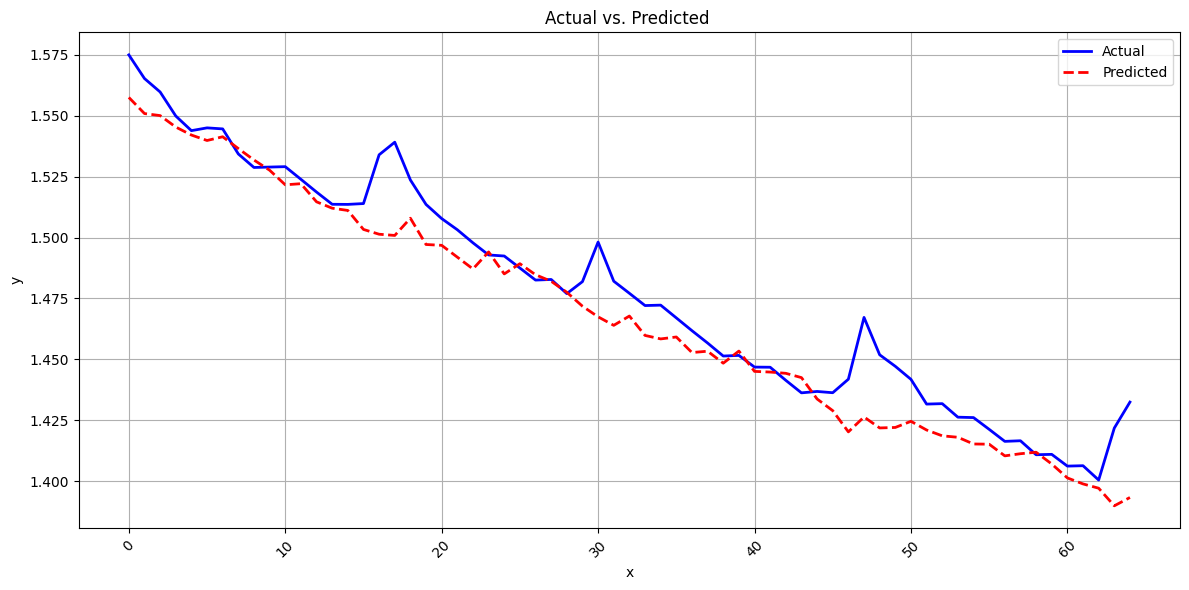

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot( true_values, label='Actual', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Actual vs. Predicted ')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()


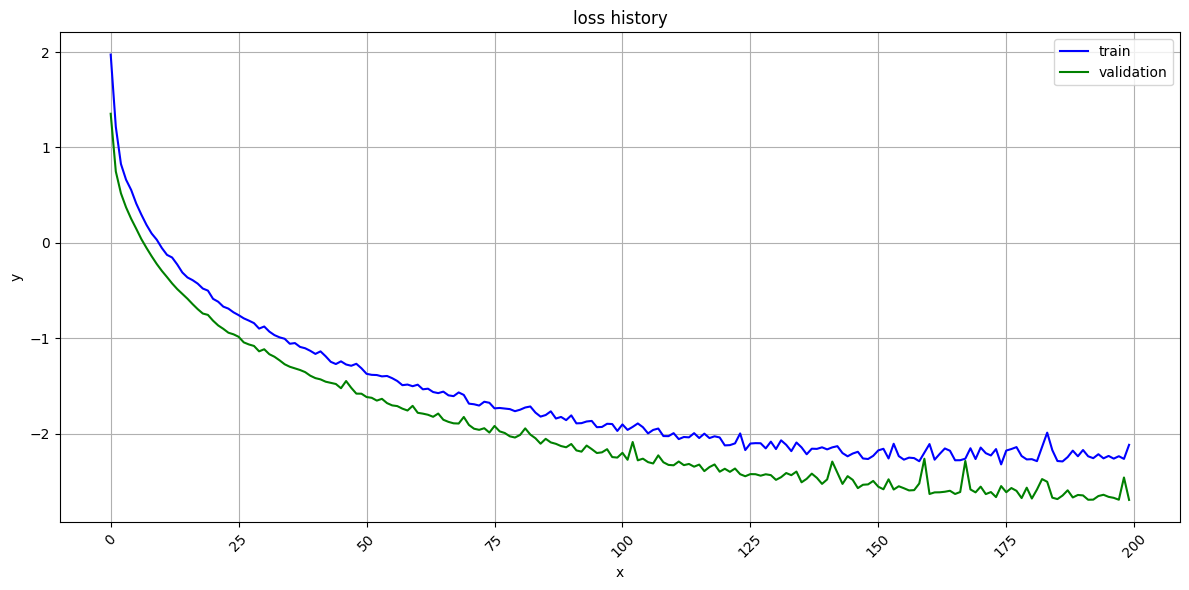

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot( loss_hitory, label='train', color='blue')
plt.plot(val_loss_history, label='validation', color='green')

# Set axis labels and a title
plt.xlabel('x')
plt.ylabel('y')
plt.title('loss history')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:

plt.rcParams["figure.figsize"] = (9,4)
plt.plot(predictions,color='red',label='Predicted RUL')
plt.plot(true_values,color='blue',label='Real RUL')
plt.plot(true_values-predictions,color='green',label='Prediction error RUL')
plt.title(' RUL Prediction')
# plt.xlabel('capacity')
# plt.ylim(0,2)
plt.ylabel('RUL')
plt.legend()
plt.show()

In [ ]:
autoformer = predictions

In [ ]:
informer = predictions

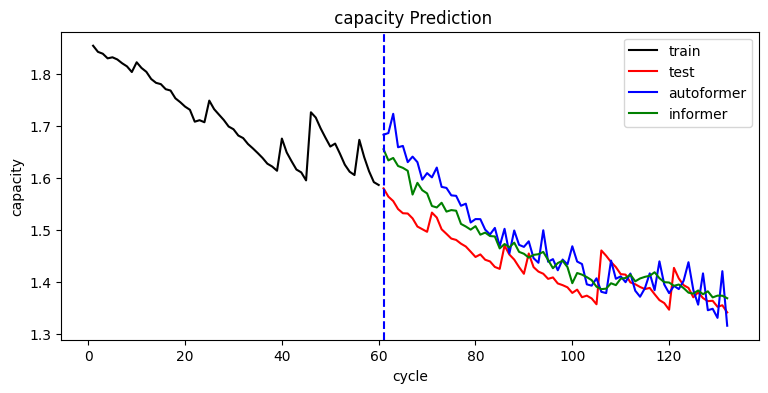

In [ ]:
plt.rcParams["figure.figsize"] = (9,4)
plt.plot(df["cycle"][:-len(predictions)],df["capacity"][:-len(predictions)],color='black',label='train')
plt.plot(df["cycle"][-len(predictions):],df["capacity"][-len(predictions):],color='red',label='test')
plt.plot(df["cycle"][-len(predictions):],autoformer,color='blue',label='autoformer')
plt.plot(df["cycle"][-len(predictions):],informer,color='green',label='informer')
plt.title(' capacity Prediction')
plt.axvline(x=len(df)-len(predictions)+1, color='blue', linestyle='--')
plt.xlabel('cycle')
# plt.ylim(0,2)
plt.ylabel('capacity')
plt.legend()
plt.show()

In [ ]:
a= input()
for i in a.split(","):
  df = pd.read_csv(f"{i}_health_index_updated.csv")
  train,test = train_test_split(df, test_size=0.75,shuffle=False)
  train_dataset = InformerDataset(train, 19)
  test_dataset = InformerDataset(test,19)
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
  configuration = AutoformerConfig(prediction_length=1,context_length=context_length,num_time_features=5,lags_sequence=[1, 2, 3, 4, 5, 6, 7])

  model = AutoformerForPrediction(configuration)
  configuration = model.config
  configuration.context_length + max(configuration.lags_sequence)
  optmizer = optim.Adam(model.parameters(),lr=1e-4)
  criterion = nn.MSELoss()
  model_name = "Informer.pt"
  loss_hitory = []
  val_loss_history = []
  model.train()
  for epoch in range(epochs):
    total_loss =0.0
    val_loss = 0.0
    for batch in train_loader:
      x,xt,y,yt = batch
      mask = torch.ones_like(x)
      y = y.unsqueeze(-1)
      yt = yt.view(yt.shape[0],1,yt.shape[1])
      outputs = model(past_values=x,past_time_features=xt,past_observed_mask=mask,future_values=y,future_time_features=yt)
      loss = outputs.loss
      loss.backward()
      optmizer.step()
      total_loss += loss.item()
      optmizer.zero_grad()
      loss_hitory.append(total_loss/len(train_loader))
    print(f"Epoch {epoch+1}/{epochs}, train Loss: {loss_hitory[-1]}")
    with torch.no_grad():
      for batch in test_loader:
        x,xt,y,yt = batch
        mask = torch.ones_like(x)
        y = y.unsqueeze(-1)
        yt = yt.view(yt.shape[0],1,yt.shape[1])
        outputs = model(past_values=x,past_time_features=xt,past_observed_mask=mask,future_values=y,future_time_features=yt)
        val_loss += outputs.loss.item()
      val_loss_history.append(val_loss/len(test_loader))
      print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {val_loss_history[-1]}")
      if val_loss_history[-1] <= min(val_loss_history):
        torch.save(model.state_dict(),model_name)
        print("Model saved")
      model.state_dict(torch.load(model_name))
      model.train()
  predictions = []
  for batch in test_loader:
    x,xt,y,yt = batch
    mask = torch.ones_like(x)
    y = y.unsqueeze(-1)
    yt = yt.view(yt.shape[0],1,yt.shape[1])
    outputs = model.generate(past_values=x,past_time_features=xt,past_observed_mask=mask,future_time_features=yt)
    mean_prediction = outputs.sequences.mean(dim=1)
    predictions.extend(mean_prediction)
  true_values = test["capacity"].values
  true_values = true_values[-len(predictions):]
  rmse = np.sqrt(mean_squared_error(true_values, predictions))
  mae = mean_absolute_error(true_values, predictions)
  test_r2 = r2_score(true_values, predictions)

  print(f"r2 score : {test_r2}")
  print(f'Root Mean Squared Error (RMSE): {rmse}')
  print(f'Mean Absolute Error (MAE): {mae}')
  with open("Autoformer.txt","a") as f:
    f.write(f"r2 score : {test_r2}\n")
    f.write(f'Root Mean Squared Error (RMSE): {rmse}\n')
    f.write(f'Mean Absolute Error (MAE): {mae}\n')

  f.close()

B0005,B0006,B0007,B0018
Epoch 1/200, train Loss: 2.112975244936736
Epoch 1/200, Validation Loss: 1.8183916183275597
Model saved


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1898: UserWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


Epoch 2/200, train Loss: 1.983094184294991
Epoch 2/200, Validation Loss: 1.657454661119764
Model saved
Epoch 3/200, train Loss: 1.762959827547488
Epoch 3/200, Validation Loss: 1.3730723657340647
Model saved
Epoch 4/200, train Loss: 1.3982553585715916
Epoch 4/200, Validation Loss: 1.048838070619886
Model saved
Epoch 5/200, train Loss: 1.117270360822263
Epoch 5/200, Validation Loss: 0.8582602923161515
Model saved
Epoch 6/200, train Loss: 1.0018124243487483
Epoch 6/200, Validation Loss: 0.7012106854224873
Model saved
Epoch 7/200, train Loss: 0.8662192691927371
Epoch 7/200, Validation Loss: 0.5255656352388525
Model saved
Epoch 8/200, train Loss: 0.5849489543748938
Epoch 8/200, Validation Loss: 0.26913679509519417
Model saved
Epoch 9/200, train Loss: 0.5583550010038458
Epoch 9/200, Validation Loss: 0.17456775597322768
Model saved
Epoch 10/200, train Loss: 0.2985129835812942
Epoch 10/200, Validation Loss: -0.058665244378776196
Model saved
Epoch 11/200, train Loss: -0.0822433466496675
Epoch 1

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1898: UserWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


Epoch 2/200, train Loss: 1.9703242260476816
Epoch 2/200, Validation Loss: 1.5777190244086434
Model saved
Epoch 3/200, train Loss: 1.7600925901661748
Epoch 3/200, Validation Loss: 1.3100665529197622
Model saved
Epoch 4/200, train Loss: 1.508631732152856
Epoch 4/200, Validation Loss: 0.9421896539001822
Model saved
Epoch 5/200, train Loss: 1.1748261918192324
Epoch 5/200, Validation Loss: 0.7697673222728979
Model saved
Epoch 6/200, train Loss: 0.9322611585907314
Epoch 6/200, Validation Loss: 0.6029398739337921
Model saved
Epoch 7/200, train Loss: 0.8438417833784352
Epoch 7/200, Validation Loss: 0.38215031265933935
Model saved
Epoch 8/200, train Loss: 0.6324579508408256
Epoch 8/200, Validation Loss: 0.18975086565886704
Model saved
Epoch 9/200, train Loss: 0.44149970878725464
Epoch 9/200, Validation Loss: 0.10798348806728826
Model saved
Epoch 10/200, train Loss: 0.1247095076934151
Epoch 10/200, Validation Loss: -0.14719157157657303
Model saved
Epoch 11/200, train Loss: 0.14034383193306302
Ep

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1898: UserWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


Epoch 2/200, train Loss: 1.763663649559021
Epoch 2/200, Validation Loss: 1.480752249744451
Model saved
Epoch 3/200, train Loss: 1.5538720721783845
Epoch 3/200, Validation Loss: 1.244242278214927
Model saved
Epoch 4/200, train Loss: 1.408158996830816
Epoch 4/200, Validation Loss: 1.09500405053112
Model saved
Epoch 5/200, train Loss: 1.1885364314784175
Epoch 5/200, Validation Loss: 0.9335804286404191
Model saved
Epoch 6/200, train Loss: 1.0175224542617798
Epoch 6/200, Validation Loss: 0.7971587025116538
Model saved
Epoch 7/200, train Loss: 0.9316096072611602
Epoch 7/200, Validation Loss: 0.6031548336287526
Model saved
Epoch 8/200, train Loss: 0.7386575755865677
Epoch 8/200, Validation Loss: 0.3969779582781212
Model saved
Epoch 9/200, train Loss: 0.5624030063981595
Epoch 9/200, Validation Loss: 0.29143556339718474
Model saved
Epoch 10/200, train Loss: 0.4824364314908567
Epoch 10/200, Validation Loss: 0.1679271752032164
Model saved
Epoch 11/200, train Loss: 0.10880775425745093
Epoch 11/200

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1898: UserWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


Epoch 2/200, train Loss: 1.9462607673236303
Epoch 2/200, Validation Loss: 1.7459603935480117
Model saved
Epoch 3/200, train Loss: 1.8532770786966597
Epoch 3/200, Validation Loss: 1.6434832572937013
Model saved
Epoch 4/200, train Loss: 1.7939951930727278
Epoch 4/200, Validation Loss: 1.5328400000929832
Model saved
Epoch 5/200, train Loss: 1.6525878650801522
Epoch 5/200, Validation Loss: 1.3935492038726807
Model saved
Epoch 6/200, train Loss: 1.5960991808346339
Epoch 6/200, Validation Loss: 1.2818175241351129
Model saved
Epoch 7/200, train Loss: 1.4112112011228288
Epoch 7/200, Validation Loss: 1.1582054391503334
Model saved
Epoch 8/200, train Loss: 1.3171801992825098
Epoch 8/200, Validation Loss: 1.0536287300288678
Model saved
Epoch 9/200, train Loss: 1.177022397518158
Epoch 9/200, Validation Loss: 0.9875130750238895
Model saved
Epoch 10/200, train Loss: 1.0656866899558477
Epoch 10/200, Validation Loss: 0.8621387250721455
Model saved
Epoch 11/200, train Loss: 0.8961441261427743
Epoch 11/

In [ ]:
df.columns

Index(['Unnamed: 0', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'Dew', 'humidity', 'Precipitation',
       'precipcover', 'windspeed', 'winddir', 'cloudcover', 'solarenergy',
       'uvindex', 'moonphase', 'icon_cloudy', 'icon_partly-cloudy-day',
       'icon_rain', 'icon_snow'],
      dtype='object')

In [ ]:
import pandas as pd

df = pd.read_csv("/content/more_processed_rainfall_data.csv")
df.drop(["icon_partly-cloudy-day", "icon_cloudy", "datetime"],inplace=True,axis=1)
df.head()

,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,Dew,humidity,Precipitation,precipcover,windspeed,winddir,cloudcover,solarenergy,uvindex,moonphase,icon_rain,icon_snow
0,0,9.3,3.3,6.5,7.6,0.1,4.6,3.8,83.3,11.3,62.50,13.0,89.9,98.5,4.3,2,0.80,True,False
1,1,9.9,0.3,4.5,7.2,-3.3,1.9,2.6,88.5,19.1,100.00,20.5,123.7,64.5,12.6,5,0.84,True,False
2,2,11.1,2.4,6.3,11.1,0.0,5.4,-2.3,55.3,1.5,33.33,10.4,4.2,39.7,14.4,6,0.94,True,False
3,3,12.7,3.2,7.6,12.7,1.0,7.1,2.3,70.2,5.2,58.33,14.8,176.2,72.5,12.4,6,0.31,True,False
4,4,19.4,6.1,11.6,19.4,4.3,10.8,0.1,49.0,1.2,29.17,16.2,281.4,18.0,20.9,8,0.62,True,False


In [ ]:
! pip install h2o
import h2o
from h2o.automl import H2OAutoML
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

# Initialize H2O cluster

h2o.init()
# Load your dataset
data =h2o.import_file(f"/content/processed_rainfall_data.csv")
target = "Precipitation"


# Split the data into training and testing sets
train, test = data.split_frame(ratios=[0.9])

# Define the predictor columns (features)
predictors = [col for col in data.columns if col != target]

# Train the AutoML model
aml = H2OAutoML(max_runtime_secs=3600)  # You can adjust the maximum runtime
aml.train(x=predictors, y=target, training_frame=train)

# Get the leader model
leader = aml.leader

# Make predictions on the test data
y_predictions = leader.predict(test)

# Evaluate model performance
performance = leader.model_performance(test)

# Calculate the requested metrics
rmse = performance.rmse()
mae = performance.mae()
mse = performance.mse()
r2 = performance.r2()

# Print the performance metrics
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")

# Shutdown H2O cluster
h2o.cluster().shutdown()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.23" 2024-04-16; OpenJDK Runtime Environment (build 11.0.23+9-post-Ubuntu-1ubuntu122.04.1); OpenJDK 64-Bit Server VM (build 11.0.23+9-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.10/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpo_r4uxmt
  JVM stdout: /tmp/tmpo_r4uxmt/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpo_r4uxmt/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,08 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.3
H2O_cluster_version_age:,8 days
H2O_cluster_name:,H2O_from_python_unknownUser_nv0jai
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.170 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Root Mean Squared Error (RMSE): 7.861313647873748
Mean Absolute Error (MAE): 5.321555593831493
Mean Squared Error (MSE): 61.800252270246055
R-squared (R^2): 0.40525843778087467
H2O session _sid_8718 closed.


In [ ]:
prediction_length=1
context_length=30
batch_size=4
epochs = 100
from transformers import InformerConfig,InformerForPrediction,AutoformerForPrediction,AutoformerConfig,PatchTSTConfig, PatchTSTForPrediction
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [ ]:
df = pd.read_csv("/content/processed_rainfall_data.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,Dew,humidity,Precipitation,precipcover,windspeed,winddir,cloudcover,solarenergy,uvindex,moonphase,icon_rain,icon_snow
0,0,0,9.3,3.3,6.5,7.6,0.1,4.6,3.8,83.3,11.3,62.50,13.0,89.9,98.5,4.3,2,0.80,True,False
1,1,1,9.9,0.3,4.5,7.2,-3.3,1.9,2.6,88.5,19.1,100.00,20.5,123.7,64.5,12.6,5,0.84,True,False
2,2,2,11.1,2.4,6.3,11.1,0.0,5.4,-2.3,55.3,1.5,33.33,10.4,4.2,39.7,14.4,6,0.94,True,False
3,3,3,12.7,3.2,7.6,12.7,1.0,7.1,2.3,70.2,5.2,58.33,14.8,176.2,72.5,12.4,6,0.31,True,False
4,4,4,19.4,6.1,11.6,19.4,4.3,10.8,0.1,49.0,1.2,29.17,16.2,281.4,18.0,20.9,8,0.62,True,False


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# df = preprocess_data(df)
train , test = train_test_split(df, test_size=0.2,shuffle=False)
# train , test = df,df1

In [ ]:
test

,Unnamed: 0.1,Unnamed: 0,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,Dew,humidity,Precipitation,precipcover,windspeed,winddir,cloudcover,solarenergy,uvindex,moonphase,icon_rain,icon_snow
1377,1377,1377,22.5,17.7,20.3,22.5,17.7,20.3,18.2,88.5,7.0,91.67,14.4,163.6,69.0,13.6,5,0.70,True,False
1378,1378,1378,24.6,18.5,21.1,24.6,18.5,21.1,19.0,88.9,6.1,70.83,15.8,205.1,87.4,19.5,8,0.80,True,False
1379,1379,1379,25.5,18.9,21.5,25.5,18.9,21.5,18.9,86.4,7.6,100.00,14.4,194.3,81.9,21.6,9,0.83,True,False
1380,1380,1380,23.6,18.5,20.6,23.6,18.5,20.6,19.0,91.1,3.4,83.33,14.8,207.1,81.3,14.0,6,0.86,True,False
1381,1381,1381,23.6,17.5,20.3,23.6,17.5,20.3,18.6,90.3,1.9,79.17,17.3,219.4,77.7,13.3,6,0.96,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1717,1717,1717,19.2,10.6,14.4,19.2,10.6,14.4,10.6,79.2,4.2,70.83,13.0,219.4,28.2,25.4,10,0.34,True,False
1718,1718,1718,18.6,10.2,13.9,18.6,10.2,13.9,10.4,80.1,6.1,70.83,13.0,212.3,19.1,26.7,10,0.37,True,False
1719,1719,1719,17.6,10.1,13.4,17.6,10.1,13.4,10.4,82.4,8.7,62.50,12.6,212.4,16.9,26.6,10,0.40,True,False
1720,1720,1720,18.3,9.7,13.6,18.3,9.7,13.6,9.7,77.7,5.2,50.00,12.6,220.3,6.1,26.6,10,0.44,True,False


In [ ]:
class InformerDataset(Dataset):
  def __init__(self, df, context_length):
    self.target = df["Precipitation"].values
    self.features = df.drop(["Unnamed: 0","Unnamed: 0.1"], axis=1).values
    self.context_length = context_length
  def __len__(self):
    return len(self.target)-self.context_length
  def __getitem__(self,idx):
    xt = self.features[idx:idx+self.context_length]
    xt = torch.tensor(np.asarray(xt,dtype=np.float32),dtype=torch.float32).to(device)
    y = self.target[idx+self.context_length]
    y = torch.tensor(np.asarray(y,dtype=np.float32),dtype=torch.float32).to(device)

    return xt,y


In [ ]:
train_dataset = InformerDataset(train, context_length)
test_dataset = InformerDataset(test,context_length)

In [ ]:
len(train_dataset)

1347

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
configuration = PatchTSTConfig(prediction_length=1,context_length=context_length,num_input_channels=18,encoder_layers=8,decoder_layers=8,d_model=728,encoder_ffn_dim=256,decoder_ffn_dim=256,encoder_attention_heads=8,decoder_attention_heads=8)

model = PatchTSTForPrediction(configuration).to(device)
configuration = model.config

In [ ]:
optmizer = optim.Adam(model.parameters(),lr=1e-3)
criterion = nn.MSELoss()
model_name = "Informer.pt"

In [ ]:
model.train()
loss_hitory = []
val_loss_history = []
for epoch in range(epochs):
  total_loss =0.0
  for batch in train_loader:
    x,y = batch
    # x = x.view(x.shape[0],x.shape[1],1)
    mask = torch.ones_like(x)
    y = y.view(y.shape[0],1,1)
    outputs = model(past_values=x,past_observed_mask=mask,future_values=y)
    loss = outputs.loss
    loss.backward()
    optmizer.step()
    total_loss += loss.item()
    optmizer.zero_grad()
  loss_hitory.append(total_loss/len(train_loader))
  print(f"Epoch {epoch+1}/{epochs}, train Loss: {loss_hitory[-1]}")

  with torch.no_grad():
    model.eval()
    val_loss = 0.0
    for batch in test_loader:
      x,y = batch

      # x = x.view(x.shape[0],x.shape[1],1)
      mask = torch.ones_like(x)
      y = y.view(y.shape[0],1,1)
      outputs = model(past_values=x,past_observed_mask=mask,future_values=y)
      val_loss += outputs.loss.item()

    val_loss_history.append(val_loss/len(test_loader))
    print(f"Epoch {epoch+1}/{epochs}, Validation Loss: {val_loss_history[-1]}")
    if val_loss_history[-1] <= min(val_loss_history):
      torch.save(model.state_dict(),model_name)
      print("Model saved")

    model.train()

model.state_dict(torch.load(model_name))

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1, 18])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([3, 1, 1])) that is different to the input size (torch.Size([3, 1, 18])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/100, train Loss: 1737.3738250732422


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([11, 1, 1])) that is different to the input size (torch.Size([11, 1, 18])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/100, Validation Loss: 1276.2913345336915
Model saved
Epoch 2/100, train Loss: 1106.941120820887
Epoch 2/100, Validation Loss: 680.3754341125489
Model saved
Epoch 3/100, train Loss: 830.2558166503907
Epoch 3/100, Validation Loss: 844.6357955932617
Epoch 4/100, train Loss: 830.436033002068
Epoch 4/100, Validation Loss: 821.5921760559082
Epoch 5/100, train Loss: 807.8465719784008
Epoch 5/100, Validation Loss: 784.8659286499023
Epoch 6/100, train Loss: 866.0195468678194
Epoch 6/100, Validation Loss: 560.6387985229492
Model saved
Epoch 7/100, train Loss: 919.7650910321404
Epoch 7/100, Validation Loss: 874.9874908447266
Epoch 8/100, train Loss: 841.9232317756204
Epoch 8/100, Validation Loss: 732.2937141418457
Epoch 9/100, train Loss: 809.6243885713465
Epoch 9/100, Validation Loss: 569.3471588134765
Epoch 10/100, train Loss: 921.6507844812729
Epoch 10/100, Validation Loss: 2258.3836029052736
Epoch 11/100, train Loss: 980.4157625086167
Epoch 11/100, Validation Loss: 880.6365768432618


In [ ]:
predictions = []

for batch in test_loader:
    x,y = batch
    # x = x.view(x.shape[0],x.shape[1],1)
    mask = torch.ones_like(x)
    outputs = model.generate(past_values=x,past_observed_mask=mask)
    mean_prediction = outputs.sequences.mean(dim=1)
    predictions.extend(mean_prediction)


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 

In [ ]:
true_values = test["Precipitation"].values
true_values = true_values[-len(predictions):]

In [ ]:
predictions = torch.tensor(predictions)

In [ ]:
predictions.shape

In [ ]:
predictions = predictions[:,:,8]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
predictions=predictions.cpu().numpy().reshape(-1)
rmse = np.sqrt(mean_squared_error(true_values, predictions))
mae = mean_absolute_error(true_values, predictions)
test_r2 = r2_score(true_values, predictions)
print(f"r2 score : {test_r2}")
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')

r2 score : -11.26344182017283
Root Mean Squared Error (RMSE): 37.10561593776376
Mean Absolute Error (MAE): 24.53424825032552


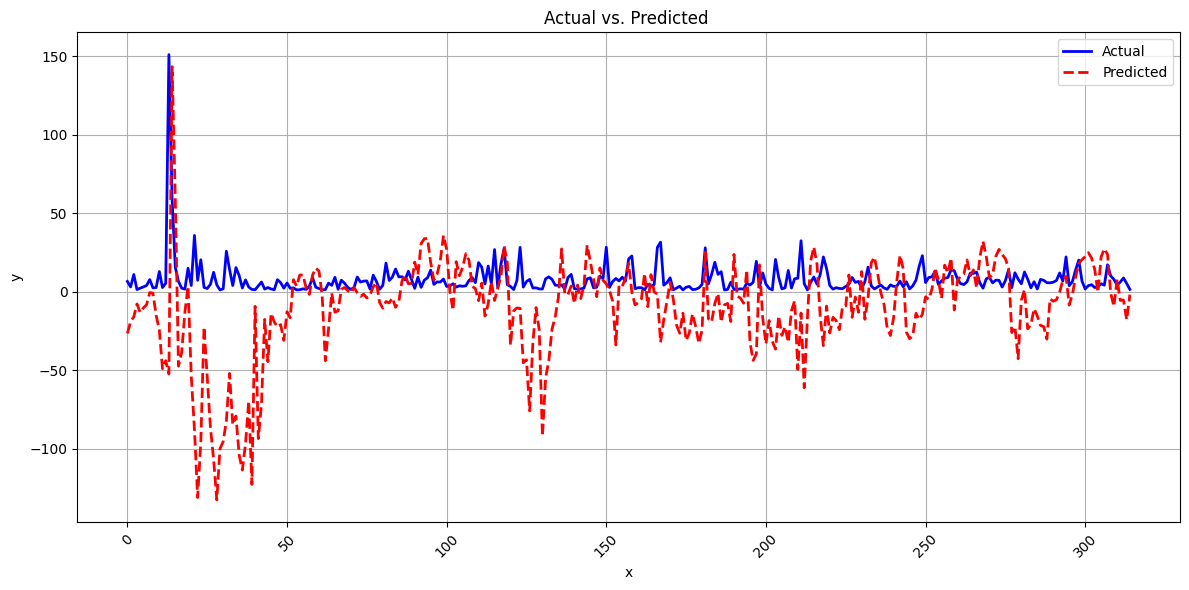

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot( true_values, label='Actual', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted', color='red', linestyle='--',linewidth=2)

# Set axis labels and a title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Actual vs. Predicted ')

# Add a legend
plt.legend()

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=45)

# Display the plot
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
r2 score : -0.548080640181676
Root Mean Squared Error (RMSE): 13.183485544347725
Mean Absolute Error (MAE): 6.744473302553571

SyntaxError: invalid syntax (<ipython-input-202-9ef55b179a5f>, line 1)